# 中国期货：已审核历史与流动性证据

本报告读取 **2026-09-07、v2 冻结输入**，展示95个品种、108个有效历史区间及换月与容量证据。读取时核对冻结文件SHA256；本报告的执行范围是读取、检查和绘图。

候选试验、旧版发布过程及数据库写入代码已归档。数据更新使用 [统一Tushare入口](../../docs/tushare_chinese_futures.md)。冻结数据的准备与各报告顺序见 [README](README.md)。历史区间仍标为全历史事后审理。

## v2 最终审理结论

已审查全部 95 个品种，发布 46 个品种的连续价格与换月日历，修改 37 行换月参数。99 个中国期货条目的名称已改为中文。全部价格保留原始存储起点，原始单合约 OHLCV 数据保持完整。

在两版共同资格日、两版均有同合约滞后 20 观察成交量的严格共同样本中，**所持合约 ADV＜70 手、产品内最大同合约 ADV≥1000 手**的“严重错月筛查”观察数由 **3926 降至 47**。1000 手是本轮筛查大市场弱月份的诊断条件。它不代表可交易容量充分，也不覆盖全部低成交日期。

| 主要问题 | 已审理的处理 |
|---|---|
| 玉米淀粉、黄大豆一号、玉米、纸浆等持有弱月份 | 调整持有周期，优先采用有足够真实成交的简单月份链 |
| 部分负 carry offset 使换月被早已到期的 carry 合约报价约束 | 采用前向 carry，逐行验证 PRICE／FORWARD／CARRY 同日真实报价 |
| 锡、镍早期弱月份 | 保留全历史足够成交的简单 FKU 周期 |
| 棉纱 2018／2019 年异常月份 | 2018 年使用 1810，2019 年由 1905 接 2001；恢复原先被弱月份遮住的有效历史 |
| 纤维板不规则活跃月份 | 人工审理月份链；每个实际换入节点要求新月滞后 ADV≥70 且双方当日有真实正成交 |
| 纤维板 2025 年两次无可靠换月重叠 | 分为三个独立可用片段，空白期间保持零资格，随后重新预热 |
| 强麦、动力煤 2022 年全产品衰退 | 强麦末段截至 2022-04-12，动力煤截至 2022-05-11 |

资格表共有 **108 个有效区间**：85 个品种单段、3 个双段、3 个三段、2 个四段。粳稻旧品种 JR 和普麦 PM 没有充分可用区间，保留明确的空政策行。原始未通过资格的价格仍可查阅。

新增全 95 品种容量诊断：在有效窗口的 **212843 个 PRICE 观察**中，同合约滞后 ADV＜70 共 **519 个观察**，其中其他月份滞后 ADV≥130 共 **181 个**。这两个计数覆盖预热阶段；第 80 个真实报价及以后仍有 **314 个**低量观察。breakout160 的原生最少窗口为 80，组合还要求 80 个真实报价观察，实际持仓由组合报告核对。

| 容量峰值品种 | 已保留历史的限制 |
|---|---|
| 沥青 BU | 2014-11-14 至 2015-01-09 持有 1506，连续 39 个观察低于 70；提前换入弱远月，产品整体成交也小，属于持续薄交易阶段 |
| 纤维板 FB | 2025-12-29／30 的 2601 均量下降，12-30 换出；换入时滞后 ADV 为 335.7 |
| 硬白小麦 WT | 2005-12-28 为 0601 最后价格观察，滞后 ADV 为 10.6，次日使用 0605；另有其他历史持续低量段 |
| 胶合板 BB | 2015-09-01 至 09-07 换入极薄 1601，共 3 个价格观察后窗口结束，换月容量有限 |
| 油菜籽 RS | 1311 在 2013-08-16 至 09-10 共 14 个价格观察持续低量，缺少可靠接续，窗口止于最后正成交报价 |
| 强麦 WH | 2101 在 2020-09-01 至 10-19 共 29 个观察低量；全产品偏弱，10-20 恢复至 70.45 |

BU 这 39 个观察的产品最佳滞后 ADV 的 P5／中位数／最大值为 **9.59／67.7／87.2**，产品当日总成交量为 **4／38／478 手**；所持月正成交占 **79.5%**，产品每天都有成交。报告保留这一可计算阶段，并明确容量限制。519 个低量观察包含持续薄交易与短暂换月衰退，审理完成不表示全部历史都能按模型持仓成交。

容量统一使用**原始同合约 VOLUME 的前 20 个观察均值**，包含零成交记录并滞后一期。旧的 `held_volume_mean20` 是有 PRICE 记录的观察链诊断；它会受缺失收盘和换月影响。其他月滞后均量较高时，也需要核对该月当天的真实成交与报价。全部原始观察内最长全产品零成交段为 RS 2018-10-15 至 11-07 的 18 个观察，位于该片段早期预热阶段；后续恢复，未见有效窗口末端持续全产品零成交段。

这些窗口及历史月份例外属于**全历史事后审理**。每个独立片段重新计算波动率与规则预热。纤维板未来月份链保留人工复核状态；黄大豆二号的最后有效片段支持原生安全续接，临时副本增量测试已通过。

正式库的 190 个价格文件与冻结输入 SHA 全部一致，95 品种的原生读取、同日报价与独立片段加法复权差分通过。发布时的恢复副本保存在运行目录的 `before_v2`，旧审理过程另存本地清理备份。

- [95 品种线性审理图册](../../private/research_runs/carry_breakout_native_2026-09-07/current_data_review_atlas.html)
- [严格共同期成交量对照](../../private/research_runs/carry_breakout_native_2026-09-07/v2_common_liquidity_comparison.csv)
- [全 95 品种低量汇总](../../private/research_runs/carry_breakout_native_2026-09-07/v2_low_volume_summary.csv)
- [全部低量日期与连续段](../../private/research_runs/carry_breakout_native_2026-09-07/v2_low_volume_blocks.csv)
- [六个容量峰值的原始证据](../../private/research_runs/carry_breakout_native_2026-09-07/v2_capacity_case_review.csv)
- [严重错月筛查剩余日期](../../private/research_runs/carry_breakout_native_2026-09-07/v2_remaining_low_adv_days.csv)
- [108 个可用历史区间](../../data/futures/csvconfig/instrument_trading_windows.csv)
- [发布与恢复证据](../../private/research_runs/carry_breakout_native_2026-09-07/promotion_v2_evidence.csv)

In [75]:
%matplotlib inline
from pathlib import Path
import hashlib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/'sysdata').is_dir() and (p/'examples/chinese_futures').is_dir())
RUN = PROJECT/'private/research_runs/carry_breakout_native_2026-09-07'
FROZEN = RUN/'v2_inputs'
CUTOFF = pd.Timestamp('2026-09-07 23:00:00')
assert (FROZEN/'volume_diagnostics.parquet').is_file(), '请先恢复README列出的2026-09-07冻结输入。'
manifest = pd.read_csv(PROJECT/'sysdata/tushare/config/futures_instruments.csv')
codes = sorted(manifest.loc[manifest.StitchMode.eq('stitch'),'Instrument'])
metadata = pd.read_csv(PROJECT/'data/futures/csvconfig/instrumentconfig.csv').set_index('Instrument')
names = metadata.Description.to_dict()
review = pd.read_csv(FROZEN/'instrument_review.csv').set_index('Instrument')
windows = pd.read_csv(FROZEN/'trading_windows.csv',parse_dates=['Start','End'])
volume = pd.read_parquet(FROZEN/'volume_diagnostics.parquet')
files = pd.read_csv(RUN/'v2_input_manifest.csv')
for row in files.itertuples():
    assert hashlib.sha256((FROZEN/row.File).read_bytes()).hexdigest()==row.SHA256, row.File
assert len(codes)==len(review)==95 and windows.Start.notna().sum()==108
assert metadata.loc[manifest.Instrument,'Description'].str.contains('[\u4e00-\u9fff]').all()
plt.style.use('default')
plt.rcParams.update({'font.family':'Arial Unicode MS','axes.grid':True,'grid.alpha':.2})
print('冻结输入SHA256通过：',len(files),'文件；95品种、108有效区间。')

冻结输入SHA256通过： 213 文件；95品种、108有效区间。


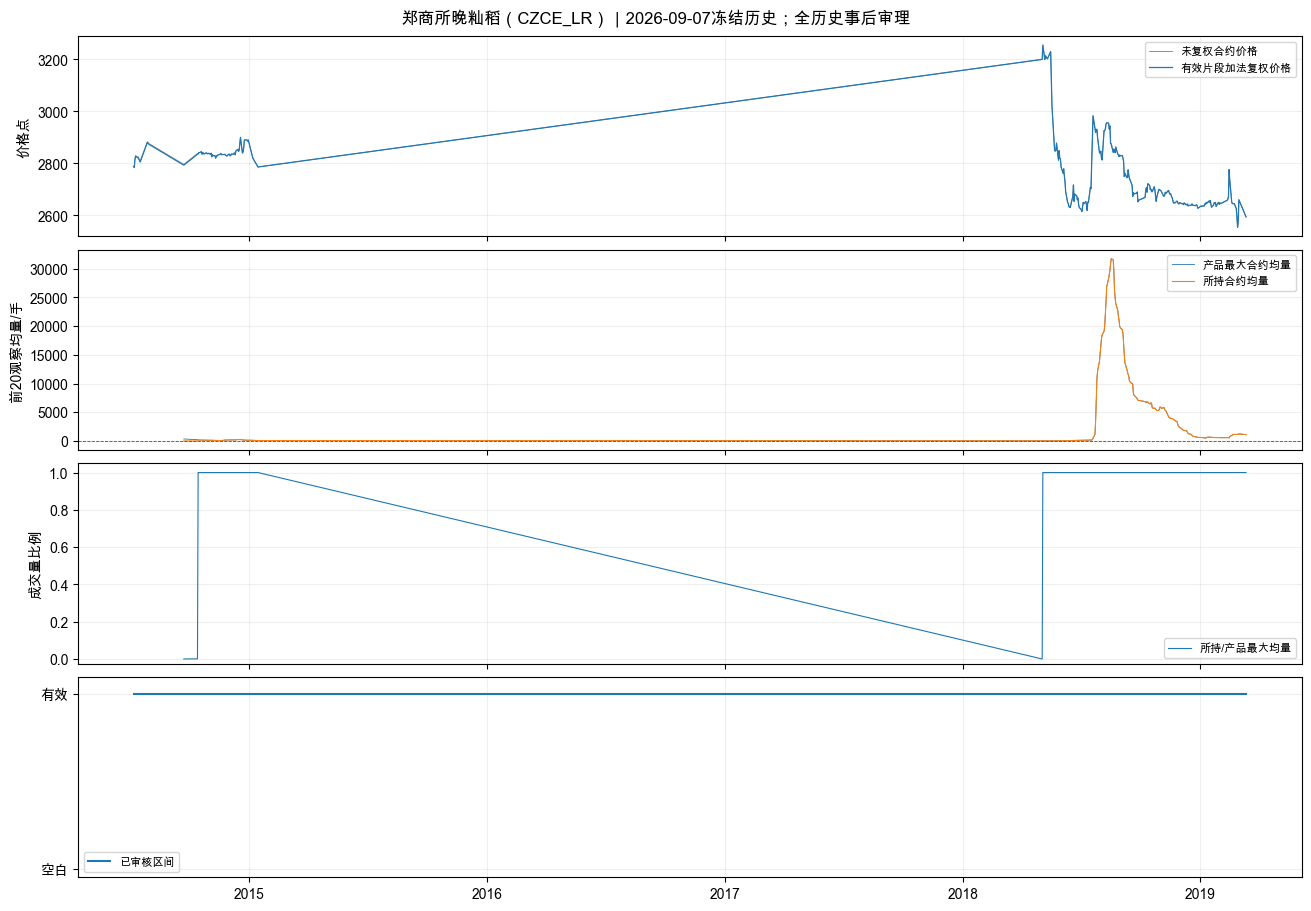

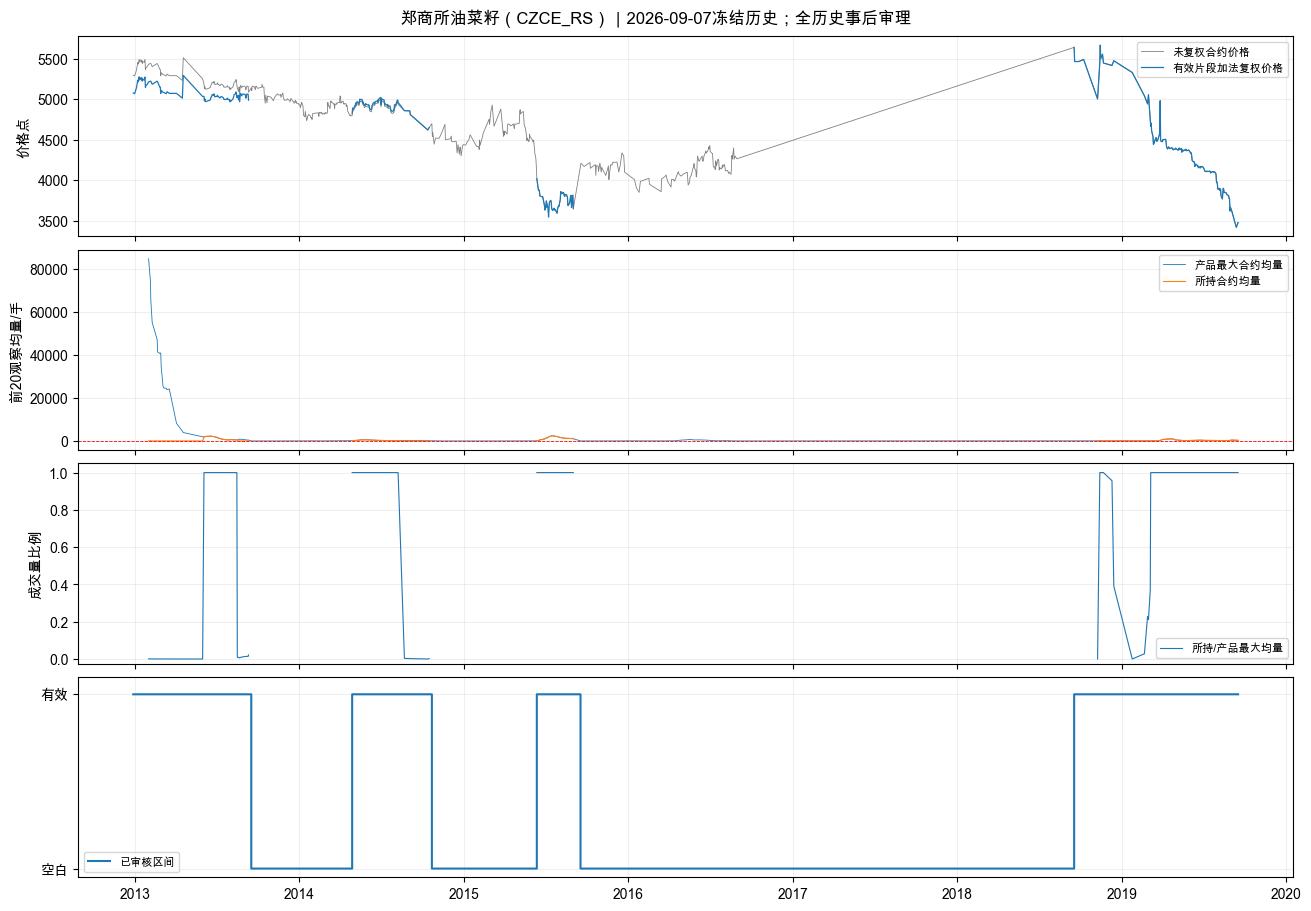

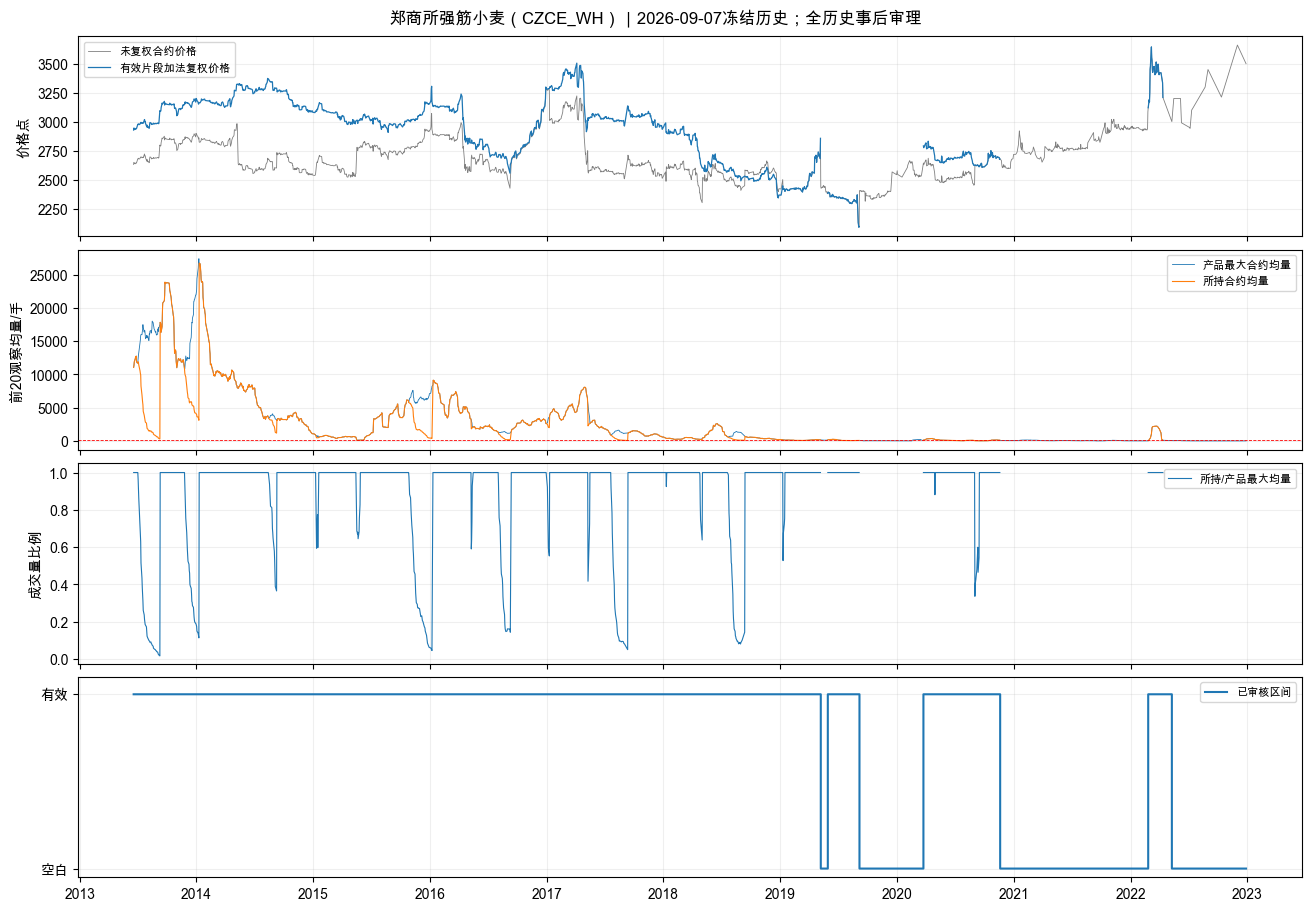

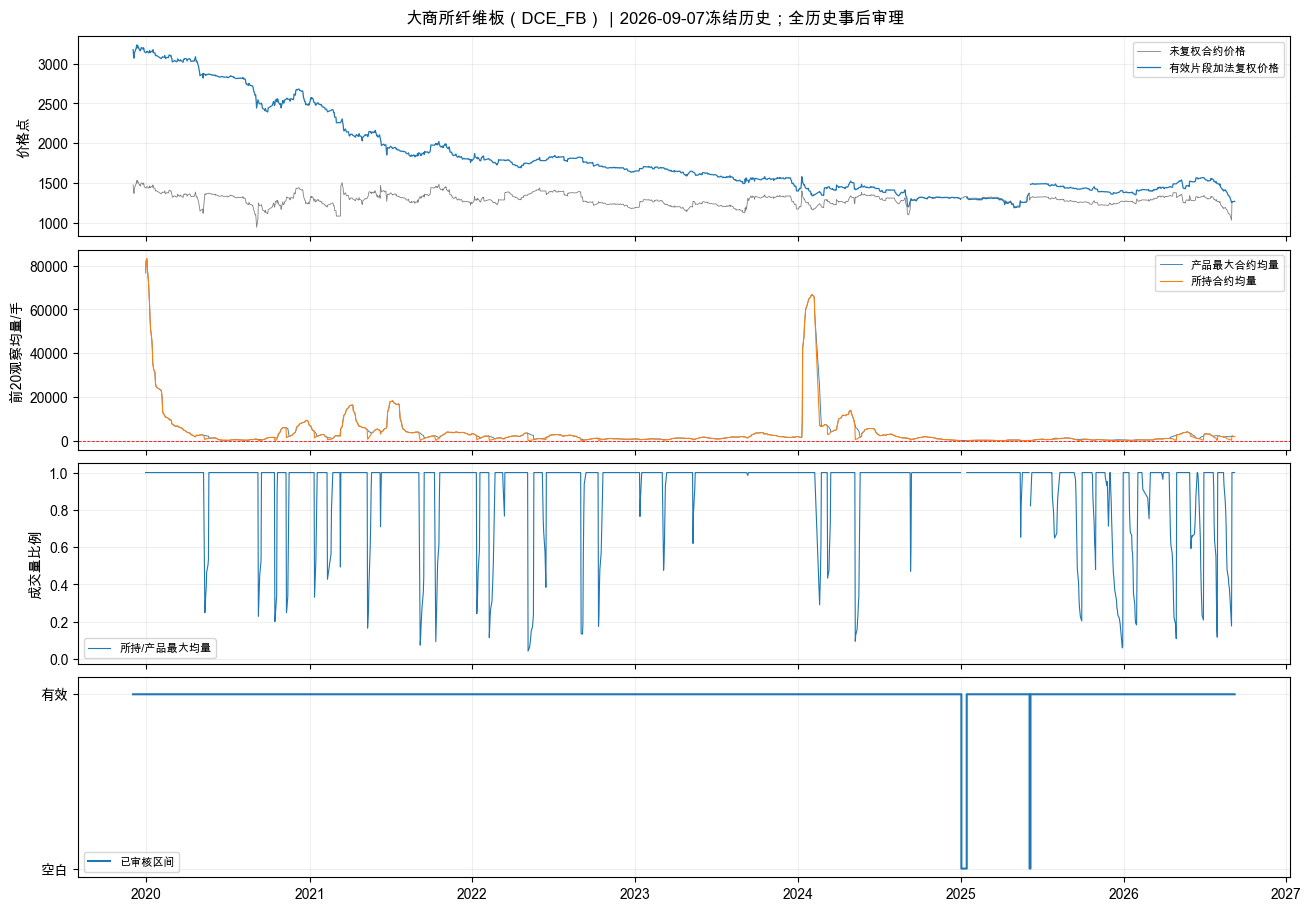

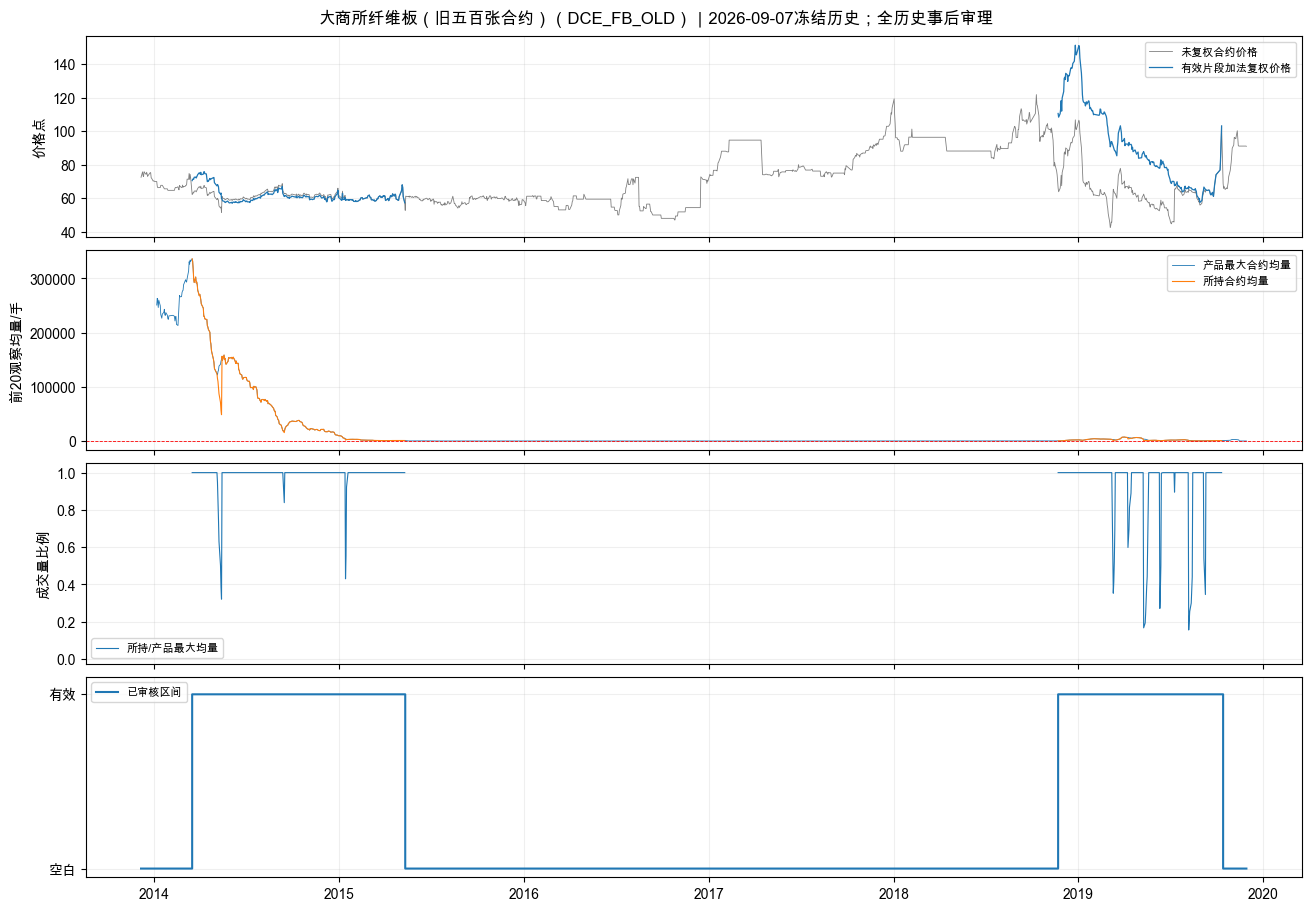

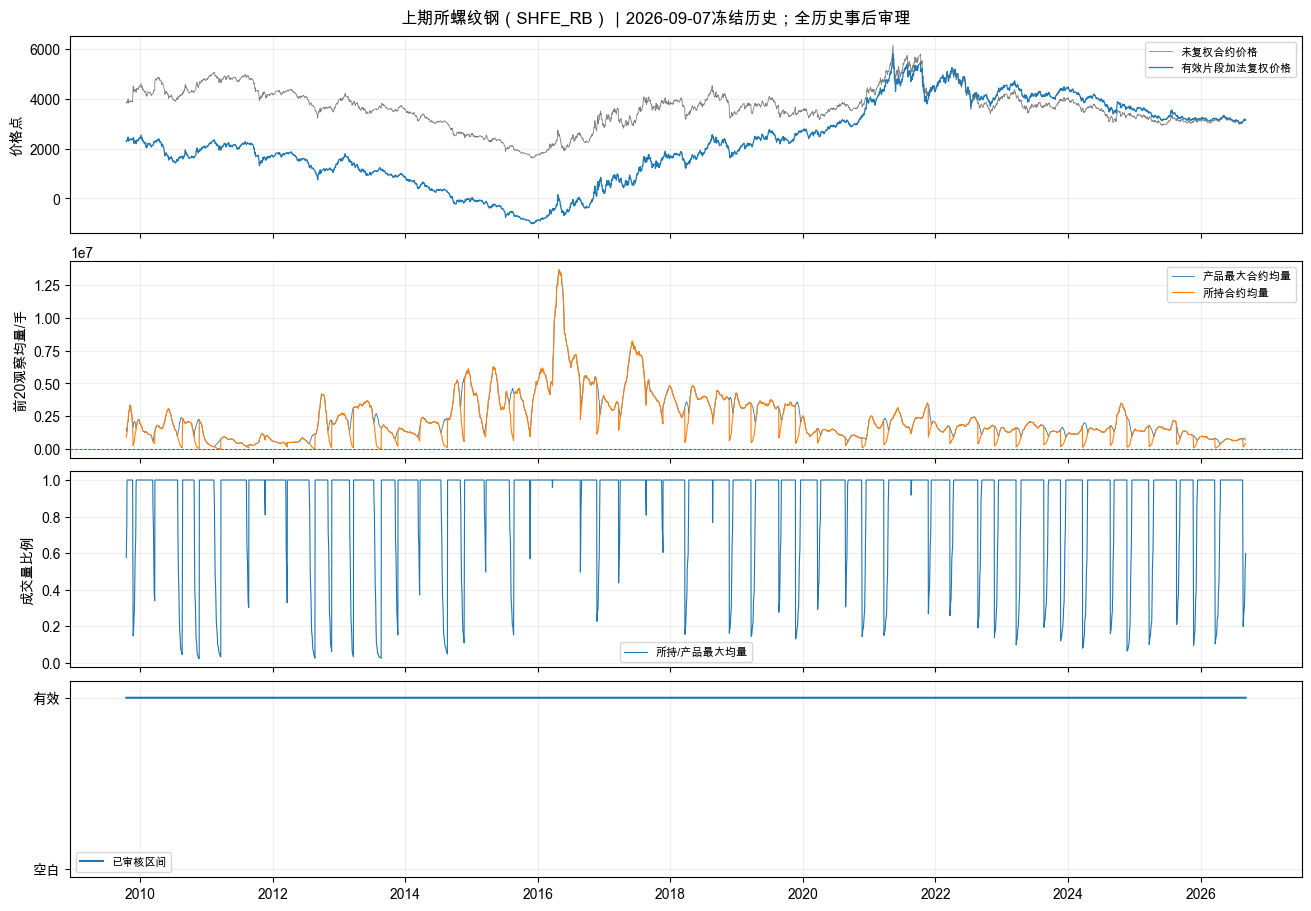

95张线性图与完整图册： /Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/current_data_review_atlas.html


In [76]:
# 仅用当前冻结输入重画95个品种；不依赖旧版价格或旧版成交量。
FIGURES = RUN/'figures_current_review'
FIGURES.mkdir(exist_ok=True)
pages = []
for number,code in enumerate(codes,1):
    d = volume.xs(code).copy()
    price = pd.read_parquet(FROZEN/f'parquet/futures_multiple_prices/{code}.parquet')
    adjusted = pd.read_parquet(FROZEN/f'parquet/futures_adjusted_prices/{code}.parquet').iloc[:,0]
    price.index,adjusted.index = price.index.normalize(),adjusted.index.normalize()
    assert price.index.is_unique and price.index.max()<=CUTOFF
    d.index = d.index.normalize()
    active = d.reviewed_window.reindex(price.index).fillna(False)
    fig,axes = plt.subplots(4,1,figsize=(13,9),sharex=True,constrained_layout=True)
    axes[0].plot(price.index,price.PRICE,color='gray',lw=.6,label='未复权合约价格')
    axes[0].plot(adjusted.index,adjusted.where(active.reindex(adjusted.index).fillna(False)),lw=.9,label='有效片段加法复权价格')
    axes[0].set_ylabel('价格点')
    axes[1].plot(d.index,d.product_contract_prior_mean20,lw=.6,label='产品最大合约均量')
    axes[1].plot(d.index,d.contract_volume_prior_mean20.where(d.reviewed_window),lw=.8,label='所持合约均量')
    axes[1].axhline(70,color='red',ls='--',lw=.6);axes[1].set_ylabel('前20观察均量/手')
    ratio = d.contract_volume_prior_mean20/d.product_contract_prior_mean20.replace(0,np.nan)
    axes[2].plot(d.index,ratio.where(d.reviewed_window),lw=.8,label='所持/产品最大均量')
    axes[2].set_ylim(-.025,1.05);axes[2].set_ylabel('成交量比例')
    axes[3].step(d.index,d.reviewed_window.astype(int),where='post',label='已审核区间')
    axes[3].set_yticks([0,1],['空白','有效']);axes[3].set_ylim(-.05,1.1)
    for ax in axes: ax.legend(fontsize=8)
    fig.suptitle(f'{names[code]}（{code}）｜2026-09-07冻结历史；全历史事后审理')
    filename = f'{code}.png'
    fig.savefig(FIGURES/filename,dpi=110)
    if code in ['SHFE_RB','DCE_FB','DCE_FB_OLD','CZCE_LR','CZCE_RS','CZCE_WH']: display(fig)
    plt.close(fig)
    pages.append(f'<section><h2>{names[code]}（{code}）</h2><img loading="lazy" src="figures_current_review/{filename}"></section>')
html = '<!doctype html><meta charset="utf-8"><title>95品种当前审核历史</title><style>body{font-family:system-ui;max-width:1200px;margin:auto}img{width:100%}</style>'+''.join(pages)
(RUN/'current_data_review_atlas.html').write_text(html)
print('95张线性图与完整图册：',RUN/'current_data_review_atlas.html')

In [77]:
# 读取已发布的逐品种原生核验；重新核对冻结文件、日期和图表覆盖。
checks = pd.read_csv(RUN/'v2_native_checks.csv')
assert len(checks)==95
assert checks[['CutoffOK','OriginalStartPreserved','UniqueDates','FiniteAdjusted']].all().all()
assert checks[['PRICEQuoteMismatch','FORWARDQuoteMismatch','CARRYQuoteMismatch']].eq(0).all().all()
assert checks.NativeAdjustedDiffMaxError.max()<1e-6
assert all((FIGURES/f'{code}.png').is_file() for code in codes)
display(checks)
print('同日报价、合约数据和独立片段复权差分的发布证据通过；冻结输入及95张图已复核。')

,Instrument,PriceRows,CutoffOK,OriginalStartPreserved,UniqueDates,PRICEQuoteMismatch,FORWARDQuoteMismatch,CARRYQuoteMismatch,NativeAdjustedDiffMaxError,FiniteAdjusted
0,CFFEX_IC,2751,True,True,True,0,0,0,0.0,True
1,CFFEX_IF,3961,True,True,True,0,0,0,0.0,True
2,CFFEX_IH,2751,True,True,True,0,0,0,0.0,True
3,CFFEX_IM,982,True,True,True,0,0,0,0.0,True
4,CFFEX_T,2683,True,True,True,0,0,0,0.0,True
5,CFFEX_TF,3113,True,True,True,0,0,0,0.0,True
6,CFFEX_TL,798,True,True,True,0,0,0,0.0,True
7,CFFEX_TS,1888,True,True,True,0,0,0,0.0,True
8,CZCE_AP,2020,True,True,True,0,0,0,0.0,True
9,CZCE_CF,5258,True,True,True,0,0,0,0.0,True


同日报价、合约数据和独立片段复权差分的发布证据通过；冻结输入及95张图已复核。


In [78]:
display(review[['Description','Status','Intervals','UsableRows','RollStatus','WeakSelectedDays','HeldPriorADVP05']]
    .rename(columns={'Description':'中文名称','Status':'审理结果','Intervals':'有效区间数','UsableRows':'观察数',
                     'RollStatus':'换月结论','WeakSelectedDays':'严重弱月份观察数','HeldPriorADVP05':'所持合约滞后均量P5'}))
display(windows)
selected = pd.read_csv(RUN/'v2_selected_candidates.csv')
roll_evidence = pd.read_csv(RUN/'v2_roll_quote_evidence.csv')
display(selected[['Instrument','Candidate','Scope','Start','End']])
display(roll_evidence.loc[roll_evidence.Instrument.isin(['DCE_FB','CZCE_LR','CZCE_RS','SHFE_RB'])].tail(30))
display(pd.read_csv(RUN/'v2_low_volume_summary.csv'))
print('完整换月逐日报价证据：',RUN/'v2_roll_quote_evidence.csv')

,中文名称,审理结果,有效区间数,观察数,换月结论,严重弱月份观察数,所持合约滞后均量P5
Instrument,,,,,,,
CFFEX_IC,中金所中证五百股指,保留单段历史,1,2751,逐品种检查后保留已审核链,0,3748.7250
CFFEX_IF,中金所沪深三百股指,保留单段历史,1,3961,逐品种检查后保留已审核链,0,6018.8375
CFFEX_IH,中金所上证五十股指,保留单段历史,1,2751,逐品种检查后保留已审核链,0,2380.6500
CFFEX_IM,中金所中证一千股指,保留单段历史,1,982,逐品种检查后保留已审核链,0,11633.6275
CFFEX_T,中金所十年期国债,保留单段历史,1,2683,逐品种检查后保留已审核链,0,12586.2650
CFFEX_TF,中金所五年期国债,保留单段历史,1,3113,逐品种检查后保留已审核链,0,1816.9200
CFFEX_TL,中金所三十年期国债,保留单段历史,1,798,逐品种检查后保留已审核链,0,10322.7200
CFFEX_TS,中金所两年期国债,保留单段历史,1,1768,逐品种检查后保留已审核链,0,3552.7625
CZCE_AP,郑商所苹果,保留单段历史,1,2020,逐品种检查后保留已审核链,0,2277.9350


,Instrument,Start,End,Reason,ReviewDate
0,CFFEX_IC,2015-05-18,2026-09-07,已审核可用历史,2026-09-07
1,CFFEX_IF,2010-05-19,2026-09-07,已审核可用历史,2026-09-07
2,CFFEX_IH,2015-05-18,2026-09-07,已审核可用历史,2026-09-07
3,CFFEX_IM,2022-08-19,2026-09-07,已审核可用历史,2026-09-07
4,CFFEX_T,2015-08-21,2026-09-07,已审核可用历史,2026-09-07
...,...,...,...,...,...
105,SHFE_SN,2015-07-16,2026-09-07,修正持有月份后按同合约滞后20观察成交量重新审理；全历史事后政策,2026-09-07
106,SHFE_SP,2019-06-13,2026-09-07,修正持有月份后按同合约滞后20观察成交量重新审理；全历史事后政策,2026-09-07
107,SHFE_SS,2020-02-14,2026-09-07,修正持有月份后按同合约滞后20观察成交量重新审理；全历史事后政策,2026-09-07
108,SHFE_WR,2009-09-14,2010-10-11,独立原生价格片段；真实正成交起止；无可靠换月重叠处保留资格空白,2026-09-07


,Instrument,Candidate,Scope,Start,End
0,CZCE_CF,原周期前向carry,完整原始起止日期,2005-01-18 23:00:00,2026-09-07 23:00:00
1,CZCE_CJ,审核周期提前30日,完整原始起止日期,2019-12-10 23:00:00,2026-09-07 23:00:00
2,CZCE_CY,补充审核提前5日,完整原始起止日期,2017-08-18 23:00:00,2026-09-07 23:00:00
3,CZCE_MA,审核周期提前30日,完整原始起止日期,2015-05-15 23:00:00,2026-09-07 23:00:00
4,CZCE_ME,原周期前向carry,完整原始起止日期,2012-05-15 23:00:00,2015-01-16 23:00:00
5,CZCE_PF,补充审核提前15日,完整原始起止日期,2021-05-10 23:00:00,2026-09-07 23:00:00
6,CZCE_PK,审核周期提前30日,完整原始起止日期,2021-10-14 23:00:00,2026-09-07 23:00:00
7,CZCE_PX,静态审核周期提前30日,完整原始起止日期,2024-05-20 23:00:00,2026-09-07 23:00:00
8,CZCE_RO,原周期前向carry,完整原始起止日期,2007-09-14 23:00:00,2013-01-16 23:00:00
9,CZCE_SA,原周期前向carry,完整原始起止日期,2020-05-19 23:00:00,2026-09-07 23:00:00


,Instrument,Date,Current,Next,Carry,IncomingPriorADV20,OutgoingPriorADV20,PRICE,PRICEVolume,FORWARD,FORWARDVolume,CARRY,CARRYVolume
1344,SHFE_RB,2016-11-21 23:00:00,20170100,20170500,20170500,1098858.40,5118987.80,2714.0,2988754.0,2738.0,1298414.0,2738.0,1298414.0
1345,SHFE_RB,2017-03-21 23:00:00,20170500,20171000,20171000,1302651.60,3318315.70,3476.0,1964284.0,3229.0,2970956.0,3229.0,2970956.0
1346,SHFE_RB,2017-08-21 23:00:00,20171000,20180100,20180100,4129802.20,3335390.90,4052.0,349440.0,3962.0,4277788.0,3962.0,4277788.0
1347,SHFE_RB,2017-11-21 23:00:00,20180100,20180500,20180500,3168641.30,1913976.40,3926.0,698156.0,3763.0,3923448.0,3763.0,3923448.0
1348,SHFE_RB,2018-03-21 23:00:00,20180500,20181000,20181000,452598.80,3099910.40,3617.0,3150512.0,3432.0,1010570.0,3432.0,1010570.0
1349,SHFE_RB,2018-08-21 23:00:00,20181000,20190100,20190100,1755310.60,2579591.00,4483.0,773658.0,4337.0,3534458.0,4337.0,3534458.0
1350,SHFE_RB,2018-11-21 23:00:00,20190100,20190500,20190500,572428.00,3780855.40,3724.0,5104664.0,3502.0,1307330.0,3502.0,1307330.0
1351,SHFE_RB,2019-03-21 23:00:00,20190500,20191000,20191000,480279.70,3473280.80,3772.0,3234998.0,3502.0,757514.0,3502.0,757514.0
1352,SHFE_RB,2019-08-21 23:00:00,20191000,20200100,20200100,799735.40,3129753.70,3686.0,2646704.0,3426.0,1648498.0,3426.0,1648498.0
1353,SHFE_RB,2019-11-21 23:00:00,20200100,20200500,20200500,419445.90,3355530.70,3619.0,4217282.0,3366.0,774116.0,3366.0,774116.0


,Instrument,Description,ReviewedPriceObservations,MissingPriorADV20,AllLowADV70Days,LowSelectedOther130Days,SevereMismatch1000Days,LowDaysWithZeroRawVolume,AllProductZeroVolumeDays,LowDaysAfter80Observations,LowOther130DaysAfter80Observations,LongestLowContractBlock,LongestOther130ContractBlock
0,CFFEX_IC,中金所中证五百股指,2751,100,0,0,0,0,0,0,0,0,0
1,CFFEX_IF,中金所沪深三百股指,3961,155,0,0,0,0,0,0,0,0,0
2,CFFEX_IH,中金所上证五十股指,2751,100,0,0,0,0,0,0,0,0,0
3,CFFEX_IM,中金所中证一千股指,982,34,0,0,0,0,0,0,0,0,0
4,CFFEX_T,中金所十年期国债,2683,0,0,0,0,0,0,0,0,0,0
5,CFFEX_TF,中金所五年期国债,3113,0,0,0,0,0,0,0,0,0,0
6,CFFEX_TL,中金所三十年期国债,798,0,0,0,0,0,0,0,0,0,0
7,CFFEX_TS,中金所两年期国债,1768,0,0,0,0,0,0,0,0,0,0
8,CZCE_AP,郑商所苹果,2020,0,0,0,0,0,0,0,0,0,0
9,CZCE_CF,郑商所棉花,5258,0,0,0,0,0,0,0,0,0,0


完整换月逐日报价证据： /Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/v2_roll_quote_evidence.csv
